In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df_full = pd.read_csv("full_dataset.csv")
df_full.columns

Index(['post_id', 'source_platform', 'post_text', 'token_count',
       'majority_label', 'normal_votes', 'offensive_votes', 'hatespeech_votes',
       'annotator_1_label', 'annotator_1_targets_text', 'annotator_2_label',
       'annotator_2_targets_text', 'annotator_3_label',
       'annotator_3_targets_text', 'rationale_count', 'post_tokens',
       'annotator_count', 'rationales', 'labels', 'annotator_1_id',
       'annotator_1_targets', 'annotator_2_id', 'annotator_2_targets',
       'annotator_3_id', 'annotator_3_targets', 'rationale_1', 'rationale_2',
       'rationale_3'],
      dtype='str')

In [3]:
df_full.shape

(20148, 28)

### Annotator IDs

In [4]:
df_1 = df_full['annotator_1_id']
df_2 = df_full['annotator_2_id']
df_3 = df_full['annotator_3_id']
df_id = pd.concat([df_1, df_2, df_3])
df_id.nunique()

253

In [5]:
df_id_count = pd.DataFrame(df_id.value_counts()).sort_values('count')
df_id_count.describe()

,count
count,253.000000
mean,238.909091
std,542.130083
min,1.000000
25%,11.000000
50%,41.000000
75%,172.000000
max,5730.000000


Text(0.5, 0.98, 'Distribution of Annotators per Annotator')

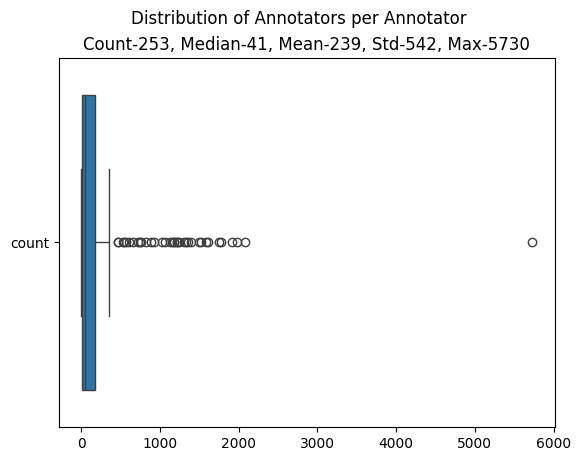

In [6]:
sns.boxplot(data = df_id_count, orient="h")
plt.title("Count-253, Median-41, Mean-239, Std-542, Max-5730")
plt.suptitle("Distribution of Annotators per Annotator")


Text(0.5, 0.98, 'Distribution of Annotations/Rows per Annotator')

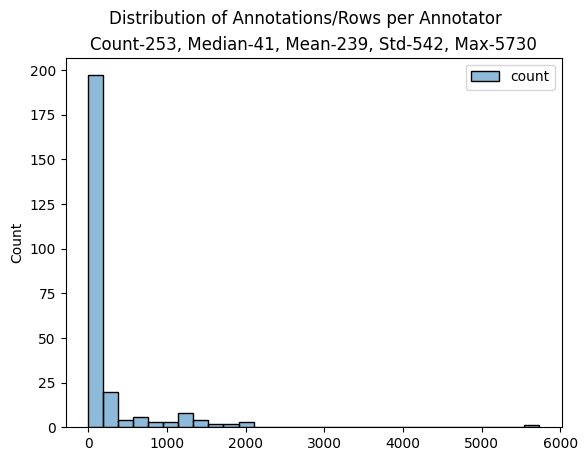

In [7]:
sns.histplot(data = df_id_count, bins = 30)
plt.title("Count-253, Median-41, Mean-239, Std-542, Max-5730")
plt.suptitle("Distribution of Annotations/Rows per Annotator")

In [8]:
df_full['source_platform'].value_counts()

source_platform
gab        11093
twitter     9027
nf            28
Name: count, dtype: int64

### Undecided Text Categ

In [9]:
# there are 919(4.6%) rows/text/posts with even split in annotator votes
round((df_full.query('normal_votes == 1 and offensive_votes == 1 and hatespeech_votes == 1').shape[0] / df_full.shape[0]),3)


0.046

In [10]:
df_full.head()

,post_id,source_platform,post_text,token_count,majority_label,normal_votes,offensive_votes,hatespeech_votes,annotator_1_label,annotator_1_targets_text,...,labels,annotator_1_id,annotator_1_targets,annotator_2_id,annotator_2_targets,annotator_3_id,annotator_3_targets,rationale_1,rationale_2,rationale_3
0,10001291_gab,gab,jews are responsible for destroying my towns c...,22,hatespeech,0,0,3,hatespeech,Jewish,...,"['hatespeech', 'hatespeech', 'hatespeech']",199,['Jewish'],200,['Jewish'],201,['Jewish'],"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",NaN
1,10002346_gab,gab,leftist mind control fails i think this overst...,33,normal,2,1,0,normal,"Men, Other",...,"['normal', 'offensive', 'normal']",202,"['Men', 'Other']",203,['Other'],204,['Women'],NaN,NaN,NaN
2,10007406_gab,gab,the scientific findings that advocates and the...,47,hatespeech,1,1,1,offensive,Homosexual,...,"['offensive', 'hatespeech', 'normal']",205,['Homosexual'],206,['Homosexual'],207,['Homosexual'],NaN,NaN,NaN
3,10008196_gab,gab,it why they behave like animals no matter wher...,52,hatespeech,1,0,2,hatespeech,African,...,"['hatespeech', 'hatespeech', 'normal']",200,['African'],208,['African'],209,['None'],"[0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",NaN
4,10009556_gab,gab,why are people so offended by the word paki su...,19,offensive,0,3,0,offensive,Asian,...,"['offensive', 'offensive', 'offensive']",27,['Asian'],1,['Arab'],52,['Arab'],"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."


In [11]:
df_full.describe()

,token_count,normal_votes,offensive_votes,hatespeech_votes,rationale_count,annotator_count,annotator_1_id,annotator_2_id,annotator_3_id
count,20148.000000,20148.000000,20148.000000,20148.000000,20148.000000,20148.0,20148.000000,20148.000000,20148.000000
mean,23.570280,1.213470,0.889666,0.896863,1.351003,3.0,121.932202,121.712230,122.317004
std,13.824308,1.238535,0.995890,1.126656,1.237148,0.0,95.469436,96.061057,96.327957
min,2.000000,0.000000,0.000000,0.000000,0.000000,3.0,1.000000,1.000000,1.000000
25%,12.000000,0.000000,0.000000,0.000000,0.000000,3.0,16.000000,11.000000,11.000000
50%,21.000000,1.000000,1.000000,0.000000,2.000000,3.0,199.000000,199.000000,199.000000
75%,34.000000,3.000000,2.000000,2.000000,2.000000,3.0,211.000000,211.000000,211.000000
max,165.000000,3.000000,3.000000,3.000000,3.000000,3.0,251.000000,253.000000,252.000000


### Target Group Labels

In [12]:
df_full[['post_id','annotator_1_targets_text', 'annotator_1_targets', 'annotator_3_targets_text']].tail(20)

,post_id,annotator_1_targets_text,annotator_1_targets,annotator_3_targets_text
20128,9929344_gab,Islam,['Islam'],Islam
20129,9941154_gab,Islam,['Islam'],Islam
20130,9968459_gab,NaN,['None'],Islam
20131,9976409_gab,Hispanic,['Hispanic'],Hispanic
20132,9976594_gab,African,['African'],NaN
20133,9976857_gab,African,['African'],African
20134,9980949_gab,NaN,['None'],"Caucasian, Arab"
20135,9981407_gab,Jewish,['Jewish'],Jewish
20136,9981575_gab,NaN,['None'],NaN
20137,9982674_gab,"Arab, Islam","['Arab', 'Islam']","Islam, Refugee"


In [13]:
df_full.dtypes.sort_values(ascending=True)

TypeError: '<' not supported between instances of 'StringDtype' and 'StringDtype'

In [14]:
# Show all rows
pd.set_option('display.max_rows', None)

# Show all columns
pd.set_option('display.max_columns', None)

In [15]:
df_full.head()

,post_id,source_platform,post_text,token_count,majority_label,normal_votes,offensive_votes,hatespeech_votes,annotator_1_label,annotator_1_targets_text,annotator_2_label,annotator_2_targets_text,annotator_3_label,annotator_3_targets_text,rationale_count,post_tokens,annotator_count,rationales,labels,annotator_1_id,annotator_1_targets,annotator_2_id,annotator_2_targets,annotator_3_id,annotator_3_targets,rationale_1,rationale_2,rationale_3
0,10001291_gab,gab,jews are responsible for destroying my towns c...,22,hatespeech,0,0,3,hatespeech,Jewish,hatespeech,Jewish,hatespeech,Jewish,2,"['jews', 'are', 'responsible', 'for', 'destroy...",3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","['hatespeech', 'hatespeech', 'hatespeech']",199,['Jewish'],200,['Jewish'],201,['Jewish'],"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",NaN
1,10002346_gab,gab,leftist mind control fails i think this overst...,33,normal,2,1,0,normal,"Men, Other",offensive,Other,normal,Women,0,"['leftist', 'mind', 'control', 'fails', 'i', '...",3,[],"['normal', 'offensive', 'normal']",202,"['Men', 'Other']",203,['Other'],204,['Women'],NaN,NaN,NaN
2,10007406_gab,gab,the scientific findings that advocates and the...,47,hatespeech,1,1,1,offensive,Homosexual,hatespeech,Homosexual,normal,Homosexual,0,"['the', 'scientific', 'findings', 'that', 'adv...",3,[],"['offensive', 'hatespeech', 'normal']",205,['Homosexual'],206,['Homosexual'],207,['Homosexual'],NaN,NaN,NaN
3,10008196_gab,gab,it why they behave like animals no matter wher...,52,hatespeech,1,0,2,hatespeech,African,hatespeech,African,normal,NaN,2,"['it', 'why', 'they', 'behave', 'like', 'anima...",3,"[[0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","['hatespeech', 'hatespeech', 'normal']",200,['African'],208,['African'],209,['None'],"[0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",NaN
4,10009556_gab,gab,why are people so offended by the word paki su...,19,offensive,0,3,0,offensive,Asian,offensive,Arab,offensive,Arab,3,"['why', 'are', 'people', 'so', 'offended', 'by...",3,"[[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,...","['offensive', 'offensive', 'offensive']",27,['Asian'],1,['Arab'],52,['Arab'],"[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ..."


In [16]:
df_1a = df_full['annotator_1_targets_text'].dropna()
df_2a = df_full['annotator_2_targets_text'].dropna()
df_3a = df_full['annotator_3_targets_text'].dropna()

In [17]:
df_target = pd.concat([df_1a, df_2a, df_3a])
print(df_target.nunique())
df_target.value_counts()

957


African                                                                                                            6320
Islam                                                                                                              3990
Jewish                                                                                                             3744
Homosexual                                                                                                         3439
Other                                                                                                              2980
Women                                                                                                              2767
Refugee                                                                                                            1954
Caucasian                                                                                                          1042
Arab                                    

In [18]:
list_target = pd.Series(df_2a).to_list()
list_target

['Jewish',
 'Other',
 'Homosexual',
 'African',
 'Arab',
 'African',
 'Homosexual',
 'Arab, Islam',
 'Other',
 'Islam',
 'Indian, Islam',
 'Refugee',
 'Islam',
 'Jewish',
 'Arab, Hispanic, Jewish, Men',
 'Other, Refugee, Homosexual',
 'African',
 'Other',
 'Other',
 'Refugee, Islam',
 'Men, Minority, Refugee, Arab, Islam, Heterosexual',
 'African',
 'African',
 'Islam',
 'Homosexual, Islam',
 'Other',
 'Arab, Jewish',
 'Arab, Islam',
 'African, Arab',
 'Islam',
 'African, Caucasian',
 'Asian, Caucasian',
 'Homosexual',
 'African',
 'African, Men, Women',
 'African',
 'Jewish',
 'Homosexual',
 'Jewish',
 'African',
 'African',
 'Homosexual',
 'Refugee, Islam',
 'Refugee',
 'Other',
 'Hispanic',
 'Islam',
 'Homosexual',
 'African',
 'Homosexual',
 'Homosexual',
 'Homosexual, Women',
 'Homosexual, Arab, Islam, Women',
 'Islam',
 'Homosexual',
 'Jewish',
 'Hindu',
 'Jewish',
 'Homosexual',
 'Arab, Islam, Refugee',
 'Islam',
 'Islam',
 'Islam',
 'Arab',
 'Homosexual',
 'Homosexual',
 'Homos

In [19]:
string_target = " ".join(list_target).replace(",", "")
clean_list_target = string_target.split(" ")
clean_list_target


['Jewish',
 'Other',
 'Homosexual',
 'African',
 'Arab',
 'African',
 'Homosexual',
 'Arab',
 'Islam',
 'Other',
 'Islam',
 'Indian',
 'Islam',
 'Refugee',
 'Islam',
 'Jewish',
 'Arab',
 'Hispanic',
 'Jewish',
 'Men',
 'Other',
 'Refugee',
 'Homosexual',
 'African',
 'Other',
 'Other',
 'Refugee',
 'Islam',
 'Men',
 'Minority',
 'Refugee',
 'Arab',
 'Islam',
 'Heterosexual',
 'African',
 'African',
 'Islam',
 'Homosexual',
 'Islam',
 'Other',
 'Arab',
 'Jewish',
 'Arab',
 'Islam',
 'African',
 'Arab',
 'Islam',
 'African',
 'Caucasian',
 'Asian',
 'Caucasian',
 'Homosexual',
 'African',
 'African',
 'Men',
 'Women',
 'African',
 'Jewish',
 'Homosexual',
 'Jewish',
 'African',
 'African',
 'Homosexual',
 'Refugee',
 'Islam',
 'Refugee',
 'Other',
 'Hispanic',
 'Islam',
 'Homosexual',
 'African',
 'Homosexual',
 'Homosexual',
 'Homosexual',
 'Women',
 'Homosexual',
 'Arab',
 'Islam',
 'Women',
 'Islam',
 'Homosexual',
 'Jewish',
 'Hindu',
 'Jewish',
 'Homosexual',
 'Arab',
 'Islam',
 'Re

In [20]:
df_target = pd.DataFrame(clean_list_target)
# df_target

df_target_count = pd.DataFrame(df_target.value_counts()).sort_values('count').reset_index()
df_target_count = df_target_count.rename(columns = {0: "target_label"})
df_target_count['target_label']

0         Bisexual
1         Buddhism
2       Indigenous
3         Economic
4     Heterosexual
5           Indian
6            Hindu
7     Nonreligious
8             None
9         Minority
10      Disability
11       Christian
12           Asian
13        Hispanic
14             Men
15       Caucasian
16            Arab
17         Refugee
18           Other
19      Homosexual
20          Jewish
21           Women
22           Islam
23         African
Name: target_label, dtype: str

Text(0.5, 1.0, 'Labeled Target Groups')

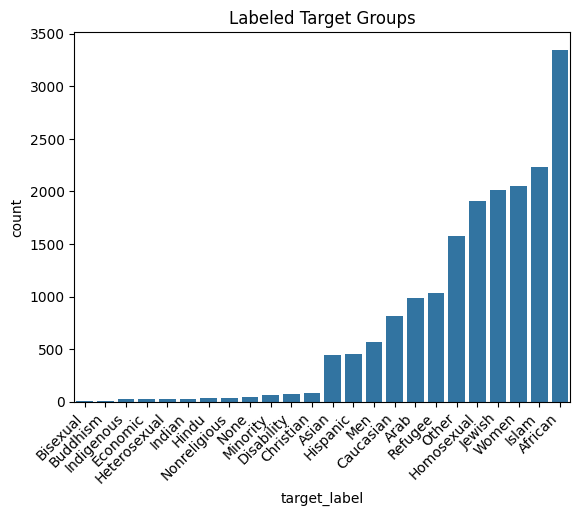

In [21]:
g = sns.barplot(data = df_target_count, x = "target_label", y = "count")
plt.xticks(rotation=45, ha='right');
plt.title("Labeled Target Groups")

In [22]:
df_full.columns

Index(['post_id', 'source_platform', 'post_text', 'token_count',
       'majority_label', 'normal_votes', 'offensive_votes', 'hatespeech_votes',
       'annotator_1_label', 'annotator_1_targets_text', 'annotator_2_label',
       'annotator_2_targets_text', 'annotator_3_label',
       'annotator_3_targets_text', 'rationale_count', 'post_tokens',
       'annotator_count', 'rationales', 'labels', 'annotator_1_id',
       'annotator_1_targets', 'annotator_2_id', 'annotator_2_targets',
       'annotator_3_id', 'annotator_3_targets', 'rationale_1', 'rationale_2',
       'rationale_3'],
      dtype='str')

In [23]:
df_full[['annotator_1_targets', 'annotator_2_targets', 'annotator_3_targets']].head(2)

,annotator_1_targets,annotator_2_targets,annotator_3_targets
0,['Jewish'],['Jewish'],['Jewish']
1,"['Men', 'Other']",['Other'],['Women']


In [24]:
# df_1a

In [25]:
# df_target = pd.DataFrame(clean_list_target)
# # df_target

# df_target_count = pd.DataFrame(df_target.value_counts()).sort_values('count').reset_index()
# df_target_count = df_target_count.rename(columns = {0: "target_label"})
df_target_count['target_label'].to_list()

['Bisexual',
 'Buddhism',
 'Indigenous',
 'Economic',
 'Heterosexual',
 'Indian',
 'Hindu',
 'Nonreligious',
 'None',
 'Minority',
 'Disability',
 'Christian',
 'Asian',
 'Hispanic',
 'Men',
 'Caucasian',
 'Arab',
 'Refugee',
 'Other',
 'Homosexual',
 'Jewish',
 'Women',
 'Islam',
 'African']

In [26]:
dict = {
    'text': df_full[['annotator_1_targets', 'annotator_2_targets', 'annotator_3_targets']]
}

In [27]:
dict = {
    'a1': df_full['annotator_1_targets'],
    'a2': df_full['annotator_2_targets'],
    'a3': df_full['annotator_3_targets'],
}

In [28]:
dict = {
    'text': df_target_count['target_label'].to_list()
}

In [29]:
# import 

In [30]:
table = {
    'Bisexual':'LGBTQ',
    'Buddhism':'Other',
    'Indigenous':'Other',
    'Economic':'Other',
    'Heterosexual':'Other',
    'Indian':'Asian',
    'Hindu':'Other',
    'Nonreligious':'Other',
    'None':'Other',
    'Minority':'Other',
    'Disability':'Other',
    'Christian':'Other',
    'Asian':'Asian',
    'Hispanic':'Hispanic',
    'Men':'Other',
    'Caucasian':'Caucasian',
    'Arab':'Arab',
    'Refugee':'Refugee',
    'Other': 'Other',
    'Homosexual':'LGBTQ',
    'Jewish':'Jewish',
    'Women':'Women',
    'Islam':'Islam',
    'African':'African'
}

In [31]:
# dict = {
#     'text':["isn't bad", "can't play"]
# }

# dict = {
#     'text': df_target_count['target_label'].to_list()
# }

# table = {
#     "isn't":"is not",
#     "can't":"cannot"
# }


df_final_target = pd.DataFrame(dict)
revised_text = []

for key in dict.keys():
    for text in dict['text']:
        words = text.split()
        for word in words:
            if word in table.keys():
                revised_text.append(text.replace(word, table[word]))

df_final_target['text1'] = revised_text
print(df_final_target)


            text      text1
0       Bisexual      LGBTQ
1       Buddhism      Other
2     Indigenous      Other
3       Economic      Other
4   Heterosexual      Other
5         Indian      Asian
6          Hindu      Other
7   Nonreligious      Other
8           None      Other
9       Minority      Other
10    Disability      Other
11     Christian      Other
12         Asian      Asian
13      Hispanic   Hispanic
14           Men      Other
15     Caucasian  Caucasian
16          Arab       Arab
17       Refugee    Refugee
18         Other      Other
19    Homosexual      LGBTQ
20        Jewish     Jewish
21         Women      Women
22         Islam      Islam
23       African    African


In [32]:
for key in dict.keys():
    print(text)

African


In [ ]:
df_full